# AMBER — Beam Prediction on DeepSense6G (scenarios 31–34)

Kaggle notebook: **stage → train → evaluate → predict**, with figures.

Implements *"AMBER: An Adaptive Multimodal Mask Transformer for Beam Prediction
with Missing Modalities"* (Wen et al.).

---

## ⚠️ Two settings to flip before Run All

In the **Settings** panel on the right:

1. **Accelerator → GPU** (T4 or P100). CPU training is not viable here.
2. **Internet → On.** Needed to clone the code and to download the pretrained
   ResNet18/34 weights AMBER initialises from.

Neither can be set from inside a notebook, so Run All stops early with a clear
message if either is off.

## What to attach

Your preprocessed dataset, via **+ Add Input**. The notebook locates it
automatically anywhere under `/kaggle/input` — it does not depend on the slug,
and it handles the doubled nesting (`development/development/...`) that Kaggle
creates.

## Splits

| split | n | used for |
|---|---|---|
| `train` | 5,544 | fitting |
| `val` | 1,350 | model selection + reported metrics |
| `adaptation` | 100 | held-out labelled check |
| `test` | 625 | **unlabelled** — predictions only, no metrics possible |

The official test release ships no `mmWave_data`, so beam history is missing for
100 % of test samples but present in ~96 % of training ones. `BEAM_DROPOUT` is
set high to stop the model depending on a signal it will not have at inference.

## 1. Environment check

In [8]:
import socket
import subprocess
import sys
from pathlib import Path

import torch

print(f"torch {torch.__version__}   cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  {p.total_memory / 1e9:.1f} GB")
else:
    raise SystemExit(
        "No GPU. Settings panel -> Accelerator -> GPU (T4 or P100), then Run All again.")


def has_internet(host="github.com", port=443, timeout=6):
    try:
        socket.create_connection((host, port), timeout=timeout).close()
        return True
    except OSError:
        return False


INTERNET = has_internet()
print(f"internet: {'on' if INTERNET else 'OFF'}")
if not INTERNET:
    raise SystemExit(
        "Internet is off, so the code cannot be cloned and the pretrained ResNet "
        "weights cannot be downloaded.\n"
        "Settings panel -> Internet -> On, then Run All again.")

torch 2.10.0+cu128   cuda available: True
GPU: Tesla T4  15.6 GB
internet: on


## 2. Locate the attached dataset

Kaggle nests inputs unpredictably — the path can be `/kaggle/input/<slug>/...`
or `/kaggle/input/datasets/<user>/<slug>/...`, and each folder is often doubled
(`development/development/...`). So nothing here assumes a depth: the index is
found by locating `samples.csv`, and each source by locating the directory that
actually contains `scenario*` folders.

In [9]:
import os

INPUT_ROOT = Path("/kaggle/input")
SOURCES = ("development", "adaptation", "test")


def walk_dirs(base, follow=True):
    # os.walk(followlinks=True) rather than Path.rglob: Kaggle sometimes exposes
    # dataset folders as symlinks, which rglob refuses to descend into
    for dirpath, dirnames, filenames in os.walk(base, followlinks=follow):
        yield Path(dirpath), dirnames, filenames


def find_index(base):
    # the directory holding samples.csv; cheap guesses first, then a full walk
    for cand in (base / "index" / "index", base / "index", base):
        if (cand / "samples.csv").exists():
            return cand
    for d, _dirs, files in walk_dirs(base):
        if "samples.csv" in files:
            return d
    return None


def find_source(base, name):
    # the directory that DIRECTLY contains scenario* folders, not its parent
    for cand in (base / name / name, base / name):
        if cand.is_dir() and any(cand.glob("scenario*")):
            return cand
    return None


INDEX_SRC = find_index(INPUT_ROOT)
if INDEX_SRC is None:
    print("directories under /kaggle/input (first 40):")
    for d, _dirs, _files in list(walk_dirs(INPUT_ROOT))[:40]:
        print("  ", d)
    raise SystemExit("Could not find samples.csv anywhere under /kaggle/input. "
                     "Attach the preprocessed dataset via + Add Input.")

# The dataset root sits just above the index, whether or not it is doubled:
#   doubled  <root>/index/index/samples.csv
#   flat     <root>/index/samples.csv
CANDIDATE_ROOTS = [INDEX_SRC.parent, INDEX_SRC.parent.parent, INDEX_SRC]

SOURCE_DIRS = {}
for s in SOURCES:
    SOURCE_DIRS[s] = next(
        (d for d in (find_source(r, s) for r in CANDIDATE_ROOTS) if d), None)

# Last resort, depth-agnostic: any directory of this name holding scenario*
# folders. Covers whatever nesting Kaggle invents.
missing = [k for k, v in SOURCE_DIRS.items() if v is None]
if missing:
    for d, dirnames, _files in walk_dirs(INPUT_ROOT):
        if d.name in missing and any(n.startswith("scenario") for n in dirnames):
            SOURCE_DIRS[d.name] = d
            missing.remove(d.name)
            if not missing:
                break

DATASET = next((r for r in CANDIDATE_ROOTS
                if any(d is not None and r in d.parents for d in SOURCE_DIRS.values())),
               INDEX_SRC.parent)

print(f"dataset root: {DATASET}")
print(f"index:        {INDEX_SRC}")
for s, d in SOURCE_DIRS.items():
    if d is None:
        print(f"  {s:<12} MISSING")
    else:
        print(f"  {s:<12} {d}  ({len(list(d.glob('scenario*')))} scenarios)")

if SOURCE_DIRS["development"] is None:
    print("\ndirectories under the dataset root (first 40):")
    for d, _dirs, _files in list(walk_dirs(DATASET))[:40]:
        print("  ", d)
    raise SystemExit("development source not found — training needs it. The paths "
                     "above should reveal the real layout.")

dataset root: /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset
index:        /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/index/index
  development  /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/development/development  (3 scenarios)
  adaptation   /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/adaptation/adaptation  (3 scenarios)
  test         /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/test/test  (4 scenarios)


## 3. Stage into the layout the loader expects

`samples.csv` stores paths as `data/processed_amber/<source>/...`, relative to a
project root. Rather than rewriting 11,868 rows, we recreate that shape under
`/kaggle/working`: the index is copied (18 MB) and each source is **symlinked**
to the read-only input, so nothing large is duplicated.

In [10]:
import shutil

import pandas as pd

STAGE = Path("/kaggle/working/data/processed_amber")
STAGE.mkdir(parents=True, exist_ok=True)
INDEX_DIR = STAGE / "index"

if not (INDEX_DIR / "samples.csv").exists():
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
    print(f"copied index -> {INDEX_DIR}")

for name, src in SOURCE_DIRS.items():
    if src is None:
        continue
    link = STAGE / name
    if not link.exists():
        link.symlink_to(src)
    print(f"{name:<12} -> {link.resolve()}")

# The loader derives its root as index_dir.parents[2]; confirm a real tensor
# path resolves before committing GPU hours to it.
_s = pd.read_csv(INDEX_DIR / "samples.csv")
ROOT = INDEX_DIR.parents[2]
_tr = _s[_s.split == "train"].iloc[0]
print(f"\nderived root: {ROOT}")
for col in ("image_1", "lidar_bev_1", "radar_1"):
    p = ROOT / _tr[col]
    print(f"  {col:<12} {'OK' if p.exists() else 'MISSING'}  {p}")
    assert p.exists(), f"{col} does not resolve — staging failed"
print("\nstaging verified")

development  -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/development/development
adaptation   -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/adaptation/adaptation
test         -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/test/test

derived root: /kaggle/working
  image_1      OK  /kaggle/working/data/processed_amber/development/scenario33/camera/image_2389.jpg
  lidar_bev_1  OK  /kaggle/working/data/processed_amber/development/scenario33/lidar_bev/lidar_data_2389.npy
  radar_1      OK  /kaggle/working/data/processed_amber/development/scenario33/radar_ra_rv/radar_data_2389.npy

staging verified


## 4. Get the code

In [11]:
import shutil

REPO_SLUG = "SathishAdithiyaaSV/MultiModal-Beam-Prediction"
PROJECT = Path("/kaggle/working/project")


def find_code(root):
    # depth-agnostic: any directory holding an amber/ package with model.py
    for d, _dirnames, filenames in walk_dirs(root):
        if d.name == "amber" and "model.py" in filenames:
            return d.parent
    return None


def try_clone(url, dest, label):
    # GIT_TERMINAL_PROMPT=0 so a private repo fails immediately instead of
    # blocking on a username prompt that a notebook can never answer
    r = subprocess.run(["git", "clone", "--depth", "1", url, str(dest)],
                       capture_output=True, text=True,
                       env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    if r.returncode == 0:
        print(f"cloned via {label}")
        return True
    detail = (r.stderr.strip().splitlines() or [""])[-1][:160]
    print(f"clone via {label} failed: {detail}")
    shutil.rmtree(dest, ignore_errors=True)
    return False


if (PROJECT / "amber" / "model.py").exists():
    print(f"code already present at {PROJECT}")
else:
    ok = False

    # 1. private repo via a GitHub token in Kaggle Secrets (Add-ons -> Secrets),
    #    stored under any of these names
    token = None
    try:
        from kaggle_secrets import UserSecretsClient

        client = UserSecretsClient()
        for key in ("GITHUB_TOKEN", "github_token", "GH_TOKEN"):
            try:
                token = client.get_secret(key)
                if token:
                    print(f"using GitHub token from secret {key!r}")
                    break
            except Exception:
                continue
    except Exception:
        pass
    if token:
        ok = try_clone(f"https://{token}@github.com/{REPO_SLUG}.git", PROJECT, "token")

    # 2. plain clone, which only works if the repo is public
    if not ok:
        ok = try_clone(f"https://github.com/{REPO_SLUG}.git", PROJECT, "public https")

    # 3. code attached as a Kaggle dataset, at any nesting depth
    if not ok:
        src = find_code(INPUT_ROOT)
        if src is not None:
            shutil.copytree(src, PROJECT, dirs_exist_ok=True)
            print(f"copied code from attached dataset: {src}")
            ok = True

    if not ok:
        raise SystemExit(
            "Could not obtain the code. The repo is private, so pick one:\n"
            "\n"
            "  A. Attach the code as a Kaggle dataset (no GitHub needed).\n"
            "     Locally: zip the amber/ and preprocessing_amber/ folders,\n"
            "     upload as a new Kaggle dataset, then + Add Input here.\n"
            "     This cell finds it automatically at any depth.\n"
            "\n"
            "  B. Add a GitHub token: create a fine-grained PAT with read access\n"
            "     to the repo, then Add-ons -> Secrets -> new secret named\n"
            "     GITHUB_TOKEN. Re-run; the repo can stay private.\n"
            "\n"
            "  C. Make the GitHub repo public, then re-run.")

os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
print(f"\ncwd = {Path.cwd()}")
print("package:", sorted(p.name for p in (PROJECT / "amber").glob("*.py")))

cloned via public https

cwd = /kaggle/working/project
package: ['__init__.py', 'cma.py', 'config.py', 'dataset.py', 'embeddings.py', 'encoders.py', 'losses.py', 'metrics.py', 'model.py', 'predict.py', 'train.py', 'transformer.py']


## 5. Index sanity check

Confirms the splits and per-modality availability before spending GPU time.
Note `m_beam` on `test`: zero, as described in the header.

In [12]:
import json

samples = pd.read_csv(INDEX_DIR / "samples.csv")
meta = json.loads((INDEX_DIR / "meta.json").read_text())

print(f"{len(samples)} rows, {len(samples.columns)} columns\n")
print("split sizes:")
print(samples.split.value_counts().to_string(), "\n")

usable = samples[samples.split.isin(["train", "val", "adaptation", "test"])]
print("modality availability (1.0 = present for every sample):")
print(usable.groupby("split")[["m_image", "m_lidar", "m_radar", "m_beam", "m_gps"]]
      .mean().round(3).to_string(), "\n")
print("samples per split and scenario:")
print(usable.groupby(["split", "scenario"]).size().to_string())
print("\nsplit policy:", json.dumps(meta["split_policy"]))

11868 rows, 41 columns

split sizes:
split
train               5544
no_target           4191
val                 1350
test                 625
adaptation           100
excluded_nan_pwr      58 

modality availability (1.0 = present for every sample):
            m_image  m_lidar  m_radar  m_beam  m_gps
split                                               
adaptation      1.0      1.0      1.0   0.000    1.0
test            1.0      1.0      1.0   0.000    1.0
train           1.0      1.0      1.0   0.966    1.0
val             1.0      1.0      1.0   0.945    1.0 

samples per split and scenario:
split       scenario  
adaptation  scenario31      50
            scenario32      25
            scenario33      25
test        scenario31     300
            scenario32      54
            scenario33     140
            scenario34     131
train       scenario32    2495
            scenario33    3049
val         scenario32     600
            scenario33     750

split policy: {"train_val_from":

## 6. Pretrained backbones

AMBER initialises from pretrained ResNet18 (radar, LiDAR) and ResNet34 (image).
Fetching them now turns a mid-training failure into an early, clear one, and
lets the run fall back to random initialisation if the download is blocked.

In [13]:
from torchvision.models import ResNet18_Weights, ResNet34_Weights

PRETRAINED = True
try:
    for w in (ResNet18_Weights.DEFAULT, ResNet34_Weights.DEFAULT):
        w.get_state_dict(progress=False)
    print("pretrained ResNet18 + ResNet34 weights cached")
except Exception as exc:
    PRETRAINED = False
    print(f"could not download weights ({type(exc).__name__}); "
          f"training from random initialisation instead.\n"
          f"Accuracy will be materially lower — enable Internet for a fair run.")
print(f"\nPRETRAINED = {PRETRAINED}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
pretrained ResNet18 + ResNet34 weights cached

PRETRAINED = True


## 7. Run configuration

In [14]:
RUN_NAME = "amber-kaggle"
RUN_DIR = Path("/kaggle/working/runs")
OUT = RUN_DIR / RUN_NAME

EPOCHS = 5               # AMBER Table II
BATCH_SIZE = 16           # AMBER Table II
LR = 1e-4                 # AMBER Table II
POOL = 4                  # VA = HA -> 16 tokens per grid modality
MODALITY_DROPOUT = 0.15
BEAM_DROPOUT = 0.50       # beam history is absent from the whole test split
WORKERS = 2
DO_ABLATION = True        # extra cell at the end; a few short eval passes

RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"outputs -> {OUT}")
print(f"{EPOCHS} epochs, batch {BATCH_SIZE}, lr {LR}, pool {POOL}")
print("\nKaggle GPU sessions are capped at ~9 h. If an epoch turns out slower "
      "than ~25 min, lower EPOCHS and re-run — training resumes from last.pt "
      "within the same session.")

outputs -> /kaggle/working/runs/amber-kaggle
20 epochs, batch 16, lr 0.0001, pool 4

Kaggle GPU sessions are capped at ~9 h. If an epoch turns out slower than ~25 min, lower EPOCHS and re-run — training resumes from last.pt within the same session.


## 8. Train

Cosine schedule with 5 warm-up steps, AdamW, focal loss on Gaussian soft labels,
weighted 10 / 0.2 / 0.2 against the contrastive and L2 terms — all per the paper.

`--beam-dropout 0.5` is **not** from the paper. It is here because beam history
vanishes entirely at test time, and AMBER's own Table V shows it is the model's
strongest cheap signal (BeamIdx+GPS alone reaches 58.81 % Top-1). Training at
the paper's uniform 0.15 yields a model that leans on it and then degrades
sharply on the real test set. Set `BEAM_DROPOUT = MODALITY_DROPOUT` for the
paper's exact recipe.

In [15]:
cmd = [sys.executable, "-m", "amber.train",
       "--index-dir", str(INDEX_DIR),
       "--run-dir", str(RUN_DIR),
       "--name", RUN_NAME,
       "--epochs", str(EPOCHS),
       "--batch-size", str(BATCH_SIZE),
       "--lr", str(LR),
       "--pool", str(POOL),
       "--modality-dropout", str(MODALITY_DROPOUT),
       "--beam-dropout", str(BEAM_DROPOUT),
       "--workers", str(WORKERS),
       "--device", "cuda",
       "--resume"]
if not PRETRAINED:
    cmd.append("--no-pretrained")

print(" ".join(cmd), "\n", flush=True)
proc = subprocess.run(cmd)
assert proc.returncode == 0, "training failed — see the output above"

/usr/bin/python3 -m amber.train --index-dir /kaggle/working/data/processed_amber/index --run-dir /kaggle/working/runs --name amber-kaggle --epochs 20 --batch-size 16 --lr 0.0001 --pool 4 --modality-dropout 0.15 --beam-dropout 0.5 --workers 2 --device cuda --resume 

device=cuda  params=49.5M  tokens/modality={'image': 16, 'lidar': 16, 'radar': 16, 'beam': 4, 'gps': 2}  N=108
  train        5544 samples
  val          1350 samples
  adaptation    100 samples
  test          625 samples
--resume given but /kaggle/working/runs/amber-kaggle/last.pt not found; starting fresh
epoch   1/20  loss 10.360 (focal 0.999 cont 1.848 l2 0.0000)  val top1 0.1978 top3 0.4378 dba 0.5706  [453.7s]
epoch   2/20  loss 6.292 (focal 0.606 cont 1.138 l2 0.0000)  val top1 0.2393 top3 0.5193 dba 0.7030  [441.6s]
epoch   3/20  loss 5.682 (focal 0.549 cont 0.937 l2 0.0000)  val top1 0.2822 top3 0.5844 dba 0.7366  [442.4s]
epoch   4/20  loss 5.465 (focal 0.530 cont 0.821 l2 0.0000)  val top1 0.3096 top3 0.5993 dba

## Figure 1 — training curves

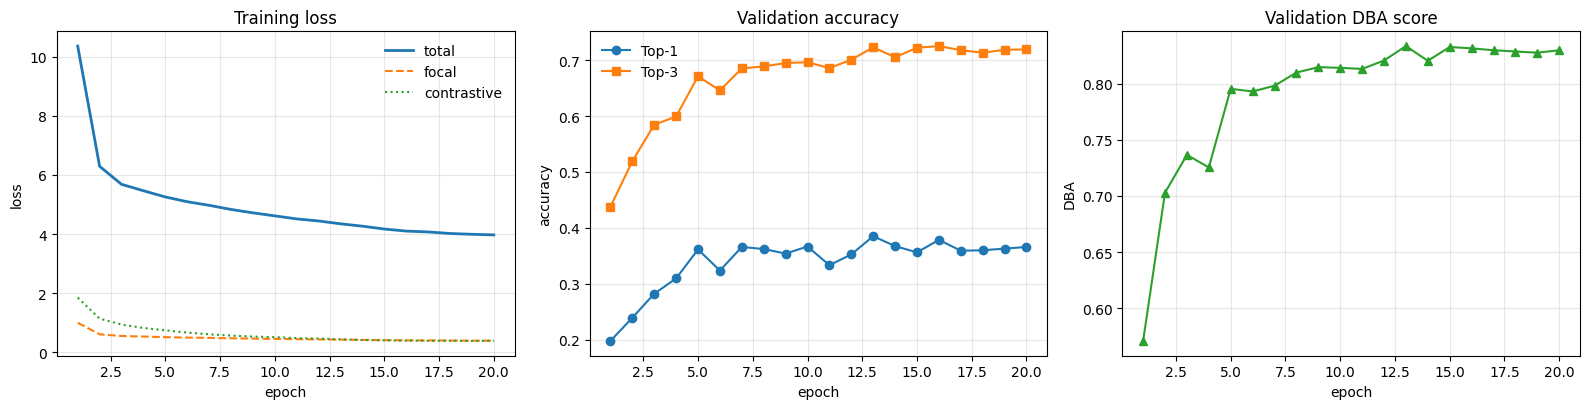

best val Top-1 0.3852 (Top-3 0.7230, DBA 0.8338) at epoch 13
mean epoch time: 7.4 min


In [16]:
import matplotlib.pyplot as plt

history = pd.read_csv(OUT / "history.csv")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].plot(history.epoch, history.loss, label="total", lw=2)
ax[0].plot(history.epoch, history.focal, label="focal", ls="--")
ax[0].plot(history.epoch, history.contrastive, label="contrastive", ls=":")
ax[0].set(xlabel="epoch", ylabel="loss", title="Training loss")
ax[0].legend(frameon=False)
ax[0].grid(alpha=.3)

ax[1].plot(history.epoch, history.val_top1, marker="o", label="Top-1")
ax[1].plot(history.epoch, history.val_top3, marker="s", label="Top-3")
ax[1].set(xlabel="epoch", ylabel="accuracy", title="Validation accuracy")
ax[1].legend(frameon=False)
ax[1].grid(alpha=.3)

ax[2].plot(history.epoch, history.val_dba, marker="^", color="tab:green")
ax[2].set(xlabel="epoch", ylabel="DBA", title="Validation DBA score")
ax[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(OUT / "fig1_training_curves.png", dpi=150)
plt.show()

best = history.loc[history.val_top1.idxmax()]
print(f"best val Top-1 {best.val_top1:.4f} (Top-3 {best.val_top3:.4f}, "
      f"DBA {best.val_dba:.4f}) at epoch {int(best.epoch)}")
print(f"mean epoch time: {history.seconds.mean() / 60:.1f} min")

## 9. Evaluate the best checkpoint

Scores the two splits that have labels, broken down per scenario, with
Top-1/3/5 and the DBA score of eqs. (37)–(39).

In [17]:
CKPT = OUT / "best.pt"
assert CKPT.exists(), "no checkpoint — did training finish an epoch?"

for split in ("val", "adaptation"):
    print(f"\n{'=' * 72}\n{split}\n{'=' * 72}", flush=True)
    subprocess.run([sys.executable, "-m", "amber.predict",
                    "--checkpoint", str(CKPT), "--index-dir", str(INDEX_DIR),
                    "--split", split, "--out-dir", str(OUT),
                    "--batch-size", "32", "--workers", str(WORKERS),
                    "--device", "cuda"], check=True)


val
checkpoint /kaggle/working/runs/amber-kaggle/best.pt  device cuda  split 'val'

1350 predictions -> /kaggle/working/runs/amber-kaggle/predictions_val.csv
top-1 only              -> /kaggle/working/runs/amber-kaggle/submission_val.csv

predicted beam spread: min 5 max 58 distinct 49
scenario
scenario32    600
scenario33    750

metrics (val):
  overall      top1=0.3852  top3=0.7230  top5=0.8867  dba=0.8338  dba_y1=0.7661  dba_y2=0.8421  dba_y3=0.8932  n=1350.0000
  scenario32   top1=0.3700  top3=0.6967  top5=0.8667  dba=0.8222  dba_y1=0.7540  dba_y2=0.8330  dba_y3=0.8797  n=600.0000
  scenario33   top1=0.3973  top3=0.7440  top5=0.9027  dba=0.8430  dba_y1=0.7757  dba_y2=0.8493  dba_y3=0.9040  n=750.0000

adaptation
checkpoint /kaggle/working/runs/amber-kaggle/best.pt  device cuda  split 'adaptation'

100 predictions -> /kaggle/working/runs/amber-kaggle/predictions_adaptation.csv
top-1 only              -> /kaggle/working/runs/amber-kaggle/submission_adaptation.csv

predicted beam sp

## Figure 2 — per-scenario performance

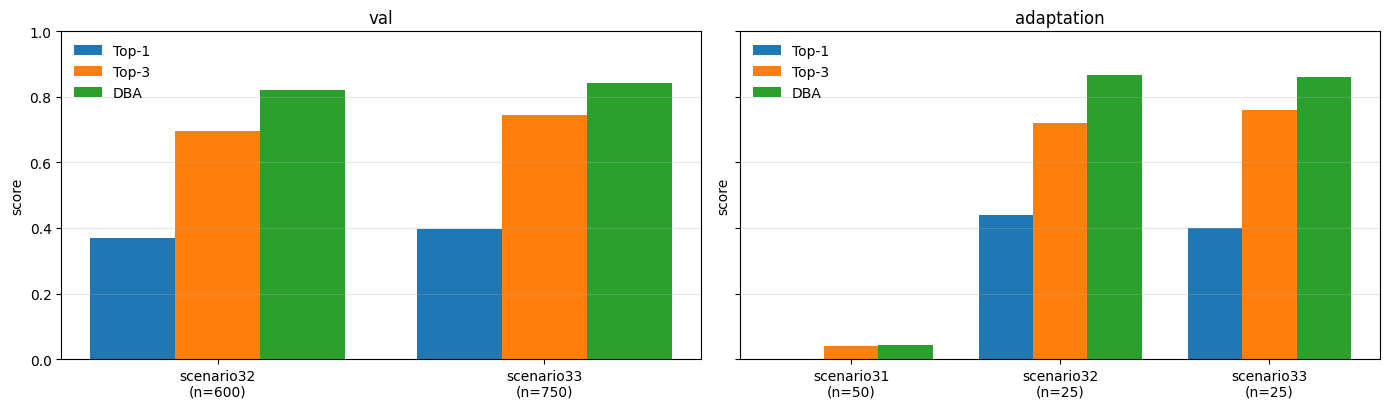

     split   scenario     n  Top-1  Top-3    DBA
       val scenario32 600.0 0.3700 0.6967 0.8222
       val scenario33 750.0 0.3973 0.7440 0.8430
adaptation scenario31  50.0 0.0000 0.0400 0.0440
adaptation scenario32  25.0 0.4400 0.7200 0.8667
adaptation scenario33  25.0 0.4000 0.7600 0.8613


In [18]:
import numpy as np

rows = []
for split in ("val", "adaptation"):
    path = OUT / f"metrics_{split}.json"
    if not path.exists():
        continue
    for group, vals in json.loads(path.read_text()).items():
        if group == "overall":
            continue
        rows.append({"split": split, "scenario": group, "n": vals["n"],
                     "Top-1": vals["top1"], "Top-3": vals["top3"], "DBA": vals["dba"]})
per_scn = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for a, split in zip(ax, ("val", "adaptation")):
    sub = per_scn[per_scn.split == split]
    if sub.empty:
        a.set_visible(False)
        continue
    x = np.arange(len(sub))
    w = 0.26
    for i, (metric, colour) in enumerate([("Top-1", "tab:blue"),
                                          ("Top-3", "tab:orange"),
                                          ("DBA", "tab:green")]):
        a.bar(x + (i - 1) * w, sub[metric], w, label=metric, color=colour)
    a.set_xticks(x)
    a.set_xticklabels([f"{s}\n(n={int(n)})" for s, n in zip(sub.scenario, sub.n)])
    a.set(title=split, ylabel="score", ylim=(0, 1))
    a.grid(alpha=.3, axis="y")
    a.legend(frameon=False)

plt.tight_layout()
plt.savefig(OUT / "fig2_per_scenario.png", dpi=150)
plt.show()
print(per_scn.round(4).to_string(index=False))

## Figure 3 — where the errors land

A 2-D histogram of true against predicted beam on `val`. Mass on the diagonal is
correct; mass *near* the diagonal is a near miss, which costs Top-1 but is
largely forgiven by DBA. This is the figure that explains any gap between the
two, and it matters here because the 64-beam power vectors in this dataset span
only ~2.6–5.6 dB, so adjacent beams are often close to equivalent in practice.

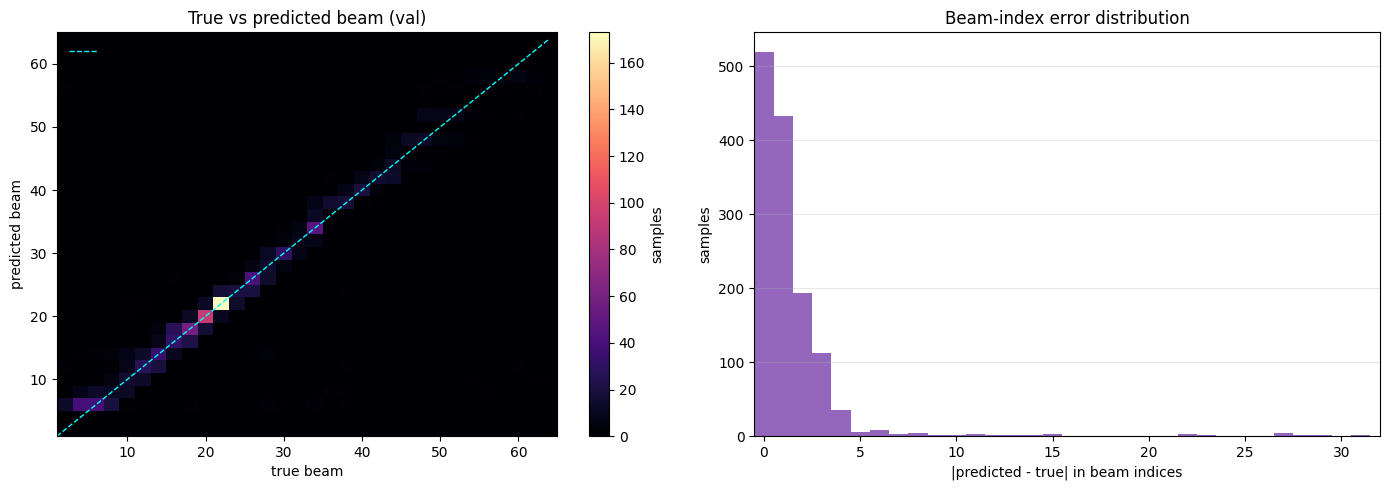

within +/-0 beams: 0.385
within +/-1 beams: 0.706
within +/-2 beams: 0.849
within +/-3 beams: 0.932
within +/-5 beams: 0.963
median absolute beam error: 1.0


In [19]:
val = pd.read_csv(OUT / "predictions_val.csv")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

h = ax[0].hist2d(val.true_beam, val.top1_beam, bins=32,
                 range=[[1, 65], [1, 65]], cmap="magma")
ax[0].plot([1, 64], [1, 64], color="cyan", lw=1, ls="--", label="perfect")
ax[0].set(xlabel="true beam", ylabel="predicted beam",
          title="True vs predicted beam (val)")
ax[0].legend(frameon=False)
fig.colorbar(h[3], ax=ax[0], label="samples")

err = (val.top1_beam - val.true_beam).abs()
ax[1].hist(err, bins=np.arange(0, 33) - .5, color="tab:purple")
ax[1].set(xlabel="|predicted - true| in beam indices", ylabel="samples",
          title="Beam-index error distribution", xlim=(-.5, 32))
ax[1].grid(alpha=.3, axis="y")

plt.tight_layout()
plt.savefig(OUT / "fig3_error_structure.png", dpi=150)
plt.show()

for tol in (0, 1, 2, 3, 5):
    print(f"within +/-{tol} beams: {(err <= tol).mean():.3f}")
print(f"median absolute beam error: {err.median():.1f}")

## 10. Predict on the official test set

The test release is unlabelled, so this produces predictions, not metrics. Beams
are written **1-indexed** to match the dataset's `unit1_beam` convention.

In [20]:
subprocess.run([sys.executable, "-m", "amber.predict",
                "--checkpoint", str(CKPT), "--index-dir", str(INDEX_DIR),
                "--split", "test", "--out-dir", str(OUT),
                "--batch-size", "32", "--workers", str(WORKERS),
                "--device", "cuda"], check=True)

test = pd.read_csv(OUT / "predictions_test.csv")
print(f"\n{len(test)} test predictions")
print(test.head(8).to_string(index=False))

n_distinct = test.top1_beam.nunique()
print(f"\ndistinct beams predicted: {n_distinct}/64")
if n_distinct < 5:
    print("WARNING: near-constant predictions — the model has not learned. "
          "Check Figure 1.")

checkpoint /kaggle/working/runs/amber-kaggle/best.pt  device cuda  split 'test'

625 predictions -> /kaggle/working/runs/amber-kaggle/predictions_test.csv
top-1 only              -> /kaggle/working/runs/amber-kaggle/submission_test.csv

predicted beam spread: min 4 max 60 distinct 48
scenario
scenario31    300
scenario32     54
scenario33    140
scenario34    131

split is unlabelled -- no metrics computable (predictions only)

625 test predictions
           sample_id   scenario  top1_beam  top1_conf  top2_beam  top2_conf  top3_beam  top3_conf  top4_beam  top4_conf  top5_beam  top5_conf
test/scenario34/2610 scenario34         58   0.050442         57   0.049953         56   0.043219         59   0.043210         55   0.034779
  test/scenario31/65 scenario31         58   0.051379         59   0.049823         55   0.047414         57   0.047007         56   0.046305
test/scenario31/2102 scenario31         59   0.041704         58   0.040350         60   0.038168         55   0.037608  

## 11. Marginal utility of each modality

Re-scores `val` with one modality masked out at a time, using AMBER's
missing-modality mask rather than retraining. The drop in Top-1 is that
modality's marginal contribution at inference — the quantity the cost-aware
routing direction of this project is built on.

        config  Top-1  Top-3    DBA  delta Top-1
all modalities 0.3852 0.7230 0.8338       0.0000
 without image 0.3474 0.6541 0.7784      -0.0378
 without lidar 0.3378 0.6941 0.8225      -0.0474
 without radar 0.3652 0.7119 0.8310      -0.0200
  without beam 0.3859 0.7111 0.8308       0.0007
   without gps 0.3481 0.6526 0.7755      -0.0370


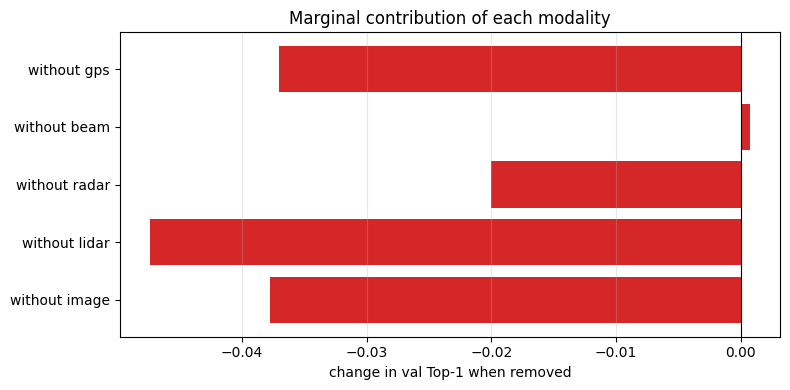

In [21]:
if DO_ABLATION:
    from amber.config import MODALITIES, TrainConfig
    from amber.dataset import AmberDataset
    from amber.metrics import evaluate
    from amber.predict import load_checkpoint
    from amber.train import make_loader, to_device

    device = torch.device("cuda")
    model, mcfg = load_checkpoint(CKPT, device)
    tcfg = TrainConfig()
    ds = AmberDataset(INDEX_DIR, "val", mcfg)
    loader = make_loader(ds, 32, shuffle=False, workers=WORKERS)

    @torch.no_grad()
    def score(drop=None):
        logits, targets = [], []
        for batch in loader:
            batch = to_device(batch, device)
            if drop is not None:
                avail = batch["availability"].clone()
                avail[:, MODALITIES.index(drop)] = 0.0
                empty = avail.sum(1) == 0      # never leave a row with nothing
                if empty.any():
                    avail[empty] = batch["availability"][empty]
                batch = {**batch, "availability": avail}
            logits.append(model(batch).logits.float().cpu())
            targets.append(batch["target"].cpu())
        logits, targets = torch.cat(logits), torch.cat(targets)
        keep = targets >= 0
        return evaluate(logits[keep], targets[keep], ks=tcfg.topk, delta=tcfg.dba_delta)

    base = score()
    table = [{"config": "all modalities", "Top-1": base["top1"],
              "Top-3": base["top3"], "DBA": base["dba"], "delta Top-1": 0.0}]
    for m in MODALITIES:
        r = score(m)
        table.append({"config": f"without {m}", "Top-1": r["top1"], "Top-3": r["top3"],
                      "DBA": r["dba"], "delta Top-1": r["top1"] - base["top1"]})
    ablation = pd.DataFrame(table)
    ablation.to_csv(OUT / "modality_ablation_val.csv", index=False)
    print(ablation.round(4).to_string(index=False))

    fig, a = plt.subplots(figsize=(8, 4))
    sub = ablation[ablation.config != "all modalities"]
    a.barh(sub.config, sub["delta Top-1"], color="tab:red")
    a.axvline(0, color="k", lw=.8)
    a.set(xlabel="change in val Top-1 when removed",
          title="Marginal contribution of each modality")
    a.grid(alpha=.3, axis="x")
    plt.tight_layout()
    plt.savefig(OUT / "fig4_modality_ablation.png", dpi=150)
    plt.show()
else:
    print("ablation skipped (DO_ABLATION = False)")

## 12. Outputs

In [22]:
print(f"{OUT}:\n")
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:<34} {p.stat().st_size / 1e6:>9.2f} MB")
print("\nEverything above is in /kaggle/working and is attached to this "
      "notebook's output when you Save Version.")

/kaggle/working/runs/amber-kaggle:

  best.pt                               198.24 MB
  config.json                             0.00 MB
  fig1_training_curves.png                0.10 MB
  fig2_per_scenario.png                   0.03 MB
  fig3_error_structure.png                0.08 MB
  fig4_modality_ablation.png              0.04 MB
  history.csv                             0.00 MB
  last.pt                               594.35 MB
  metrics.json                            0.00 MB
  metrics_adaptation.json                 0.00 MB
  metrics_val.json                        0.00 MB
  modality_ablation_val.csv               0.00 MB
  predictions_adaptation.csv              0.01 MB
  predictions_test.csv                    0.06 MB
  predictions_val.csv                     0.14 MB
  submission_adaptation.csv               0.00 MB
  submission_test.csv                     0.00 MB
  submission_val.csv                      0.00 MB

Everything above is in /kaggle/working and is attached to this 

## Troubleshooting

**Stops at the environment check.** Accelerator and Internet live in the
Settings panel and cannot be set from code. Flip them, then Run All.

**Clone fails.** The repo may be private. Either make it public, or attach the
code (`amber/` and `preprocessing_amber/`) as a second Kaggle dataset — the
notebook picks that up automatically.

**Out of memory.** Lower `BATCH_SIZE` to 8, or `POOL` to 2 (4 tokens per grid
modality instead of 16).

**Session ended mid-training.** Re-run the training cell; `--resume` continues
from `last.pt`. Across *different* sessions `/kaggle/working` is reset, so save
a version first or expect to start over.

**One beam predicted for everything.** Normal for the first epochs. If it
persists past ~5, check that `focal` is falling in Figure 1.

## Known data limitations

- **Scenario 34 contributes no training data** — the development release ships
  no radar, vehicle GPS or power files, so its 4,191 samples sit in `no_target`.
  Only scenarios 32 and 33 feed `train`/`val`.
- **Scenario 31 has no training data at all** — it appears only in `adaptation`
  (100 samples) and the unlabelled `test` split.
- **58 development samples have corrupt labels** and are quarantined in
  `excluded_nan_pwr`.

So per-scenario numbers cover 32/33 on `val` and 31/32/33 on `adaptation`. The
paper's per-scenario S31/S34 results need the full per-scenario DeepSense6G
releases, which are a separate download.